<style>
h1, h1 *, 
h2, h2 *, 
h3, h3 *, 
h4, h4 *, 
h5, h5 *, 
h6, h6 * {
  font-family: "Times New Roman", Times, serif !important;

</style>

### **Hotel Booking Cancellations Prediction**

---

In [1]:
import sys
!{sys.executable} -m pip install streamlit

In [2]:
import sys
!{sys.executable} -m pip install joblib

In [3]:
import pandas as pd
import warnings

warnings.filterwarnings('ignore')

In [4]:
df = pd.read_excel('Hotel Booking Cancellations Prediction - Dataset.xlsx')

In [5]:
df

,no_of_adults,no_of_children,no_of_weekend_nights,no_of_week_nights,type_of_meal_plan,required_car_parking_space,lead_time,arrival_year,arrival_month,arrival_date,repeated_guest,no_of_previous_cancellations,no_of_previous_bookings_not_canceled,avg_price_per_room,no_of_special_requests,booking_status
0,2,0,1,2,Meal Plan 1,0,224,2017,10,2,0,0,0,65.00,0,Not_Canceled
1,2,0,2,3,Not Selected,0,5,2018,11,6,0,0,0,106.68,1,Not_Canceled
2,1,0,2,1,Meal Plan 1,0,1,2018,2,28,0,0,0,60.00,0,Canceled
3,2,0,0,2,Meal Plan 1,0,211,2018,5,20,0,0,0,100.00,0,Canceled
4,2,0,1,1,Not Selected,0,48,2018,4,11,0,0,0,94.50,0,Canceled
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
25806,2,2,0,1,Meal Plan 1,0,0,2018,10,6,0,0,0,216.00,0,Canceled
25807,3,0,2,6,Meal Plan 1,0,85,2018,8,3,0,0,0,167.80,1,Not_Canceled
25808,2,0,1,3,Meal Plan 1,0,228,2018,10,17,0,0,0,90.95,2,Canceled
25809,2,0,2,6,Meal Plan 1,0,148,2018,7,1,0,0,0,98.39,2,Not_Canceled


In [6]:
df.head()

,no_of_adults,no_of_children,no_of_weekend_nights,no_of_week_nights,type_of_meal_plan,required_car_parking_space,lead_time,arrival_year,arrival_month,arrival_date,repeated_guest,no_of_previous_cancellations,no_of_previous_bookings_not_canceled,avg_price_per_room,no_of_special_requests,booking_status
0,2,0,1,2,Meal Plan 1,0,224,2017,10,2,0,0,0,65.00,0,Not_Canceled
1,2,0,2,3,Not Selected,0,5,2018,11,6,0,0,0,106.68,1,Not_Canceled
2,1,0,2,1,Meal Plan 1,0,1,2018,2,28,0,0,0,60.00,0,Canceled
3,2,0,0,2,Meal Plan 1,0,211,2018,5,20,0,0,0,100.00,0,Canceled
4,2,0,1,1,Not Selected,0,48,2018,4,11,0,0,0,94.50,0,Canceled


In [7]:
df.dtypes

no_of_adults                              int64
no_of_children                            int64
no_of_weekend_nights                      int64
no_of_week_nights                         int64
type_of_meal_plan                        object
required_car_parking_space                int64
lead_time                                 int64
arrival_year                              int64
arrival_month                             int64
arrival_date                              int64
repeated_guest                            int64
no_of_previous_cancellations              int64
no_of_previous_bookings_not_canceled      int64
avg_price_per_room                      float64
no_of_special_requests                    int64
booking_status                           object
dtype: object

In [8]:
df.shape

(25811, 16)

In [9]:
df.describe()

,no_of_adults,no_of_children,no_of_weekend_nights,no_of_week_nights,required_car_parking_space,lead_time,arrival_year,arrival_month,arrival_date,repeated_guest,no_of_previous_cancellations,no_of_previous_bookings_not_canceled,avg_price_per_room,no_of_special_requests
count,25811.000000,25811.000000,25811.000000,25811.000000,25811.000000,25811.000000,25811.000000,25811.000000,25811.000000,25811.000000,25811.000000,25811.000000,25811.000000,25811.000000
mean,1.890744,0.142265,0.883034,2.263918,0.042424,65.548836,2017.850490,7.331099,15.752780,0.033009,0.028747,0.214676,105.747677,0.746426
std,0.529264,0.464034,0.887990,1.514417,0.201558,67.452796,0.356597,3.143281,8.854341,0.178664,0.410378,2.075722,37.916084,0.815896
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,2017.000000,1.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,2.000000,0.000000,0.000000,1.000000,0.000000,12.000000,2018.000000,5.000000,8.000000,0.000000,0.000000,0.000000,80.750000,0.000000
50%,2.000000,0.000000,1.000000,2.000000,0.000000,44.000000,2018.000000,8.000000,16.000000,0.000000,0.000000,0.000000,100.000000,1.000000
75%,2.000000,0.000000,2.000000,3.000000,0.000000,98.000000,2018.000000,10.000000,23.000000,0.000000,0.000000,0.000000,127.000000,1.000000
max,4.000000,10.000000,7.000000,17.000000,1.000000,443.000000,2018.000000,12.000000,31.000000,1.000000,13.000000,58.000000,540.000000,5.000000


In [10]:
df.describe(include = 'object')

,type_of_meal_plan,booking_status
count,25811,25811
unique,4,2
top,Meal Plan 1,Not_Canceled
freq,20265,18542


In [11]:
df['booking_status'].value_counts()

booking_status
Not_Canceled    18542
Canceled         7269
Name: count, dtype: int64

In [12]:
df.head()

,no_of_adults,no_of_children,no_of_weekend_nights,no_of_week_nights,type_of_meal_plan,required_car_parking_space,lead_time,arrival_year,arrival_month,arrival_date,repeated_guest,no_of_previous_cancellations,no_of_previous_bookings_not_canceled,avg_price_per_room,no_of_special_requests,booking_status
0,2,0,1,2,Meal Plan 1,0,224,2017,10,2,0,0,0,65.00,0,Not_Canceled
1,2,0,2,3,Not Selected,0,5,2018,11,6,0,0,0,106.68,1,Not_Canceled
2,1,0,2,1,Meal Plan 1,0,1,2018,2,28,0,0,0,60.00,0,Canceled
3,2,0,0,2,Meal Plan 1,0,211,2018,5,20,0,0,0,100.00,0,Canceled
4,2,0,1,1,Not Selected,0,48,2018,4,11,0,0,0,94.50,0,Canceled


In [13]:
df['total_guests'] = df['no_of_adults'] + df['no_of_children']

In [14]:
df.head()

,no_of_adults,no_of_children,no_of_weekend_nights,no_of_week_nights,type_of_meal_plan,required_car_parking_space,lead_time,arrival_year,arrival_month,arrival_date,repeated_guest,no_of_previous_cancellations,no_of_previous_bookings_not_canceled,avg_price_per_room,no_of_special_requests,booking_status,total_guests
0,2,0,1,2,Meal Plan 1,0,224,2017,10,2,0,0,0,65.00,0,Not_Canceled,2
1,2,0,2,3,Not Selected,0,5,2018,11,6,0,0,0,106.68,1,Not_Canceled,2
2,1,0,2,1,Meal Plan 1,0,1,2018,2,28,0,0,0,60.00,0,Canceled,1
3,2,0,0,2,Meal Plan 1,0,211,2018,5,20,0,0,0,100.00,0,Canceled,2
4,2,0,1,1,Not Selected,0,48,2018,4,11,0,0,0,94.50,0,Canceled,2


In [15]:
df['total_nights'] = df['no_of_weekend_nights'] + df['no_of_week_nights']

In [16]:
df.head()

,no_of_adults,no_of_children,no_of_weekend_nights,no_of_week_nights,type_of_meal_plan,required_car_parking_space,lead_time,arrival_year,arrival_month,arrival_date,repeated_guest,no_of_previous_cancellations,no_of_previous_bookings_not_canceled,avg_price_per_room,no_of_special_requests,booking_status,total_guests,total_nights
0,2,0,1,2,Meal Plan 1,0,224,2017,10,2,0,0,0,65.00,0,Not_Canceled,2,3
1,2,0,2,3,Not Selected,0,5,2018,11,6,0,0,0,106.68,1,Not_Canceled,2,5
2,1,0,2,1,Meal Plan 1,0,1,2018,2,28,0,0,0,60.00,0,Canceled,1,3
3,2,0,0,2,Meal Plan 1,0,211,2018,5,20,0,0,0,100.00,0,Canceled,2,2
4,2,0,1,1,Not Selected,0,48,2018,4,11,0,0,0,94.50,0,Canceled,2,2


In [17]:
df['booking_status'].value_counts(normalize = True)

booking_status
Not_Canceled    0.718376
Canceled        0.281624
Name: proportion, dtype: float64

In [18]:
import seaborn as sns
import matplotlib.pyplot as plt
from matplotlib import rcParams

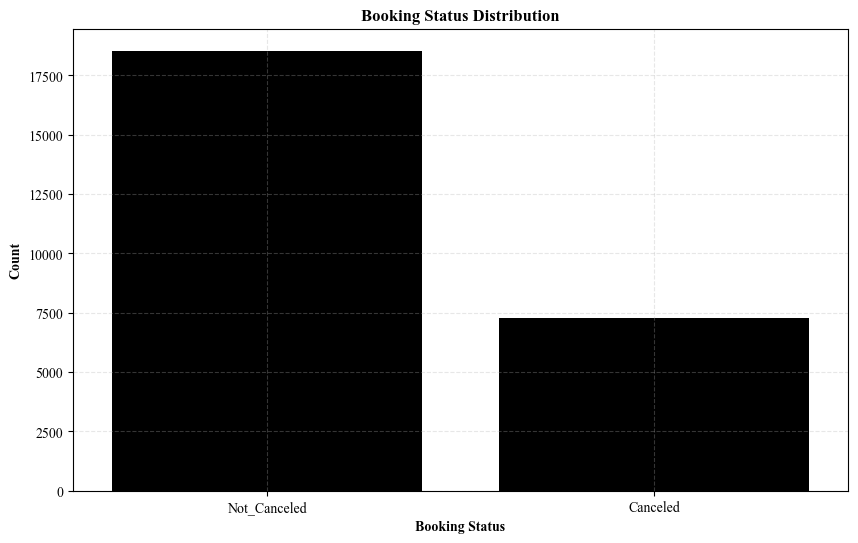

In [19]:
rcParams['font.family'] = 'Times New Roman'

fig, ax = plt.subplots(figsize = (10, 6))
sns.countplot(data = df, x = 'booking_status', ax = ax, color = 'black')
ax.set_title('Booking Status Distribution', fontweight = 'bold', fontsize = 12)
ax.set_xlabel('Booking Status', fontweight = 'bold')
ax.set_ylabel('Count', fontweight = 'bold')
ax.grid(True, linestyle = '--', alpha = 0.3)

plt.show()

In [20]:
num_cols = df.select_dtypes(include = ['int64', 'float64']).columns

In [21]:
num_cols

Index(['no_of_adults', 'no_of_children', 'no_of_weekend_nights',
       'no_of_week_nights', 'required_car_parking_space', 'lead_time',
       'arrival_year', 'arrival_month', 'arrival_date', 'repeated_guest',
       'no_of_previous_cancellations', 'no_of_previous_bookings_not_canceled',
       'avg_price_per_room', 'no_of_special_requests', 'total_guests',
       'total_nights'],
      dtype='object')

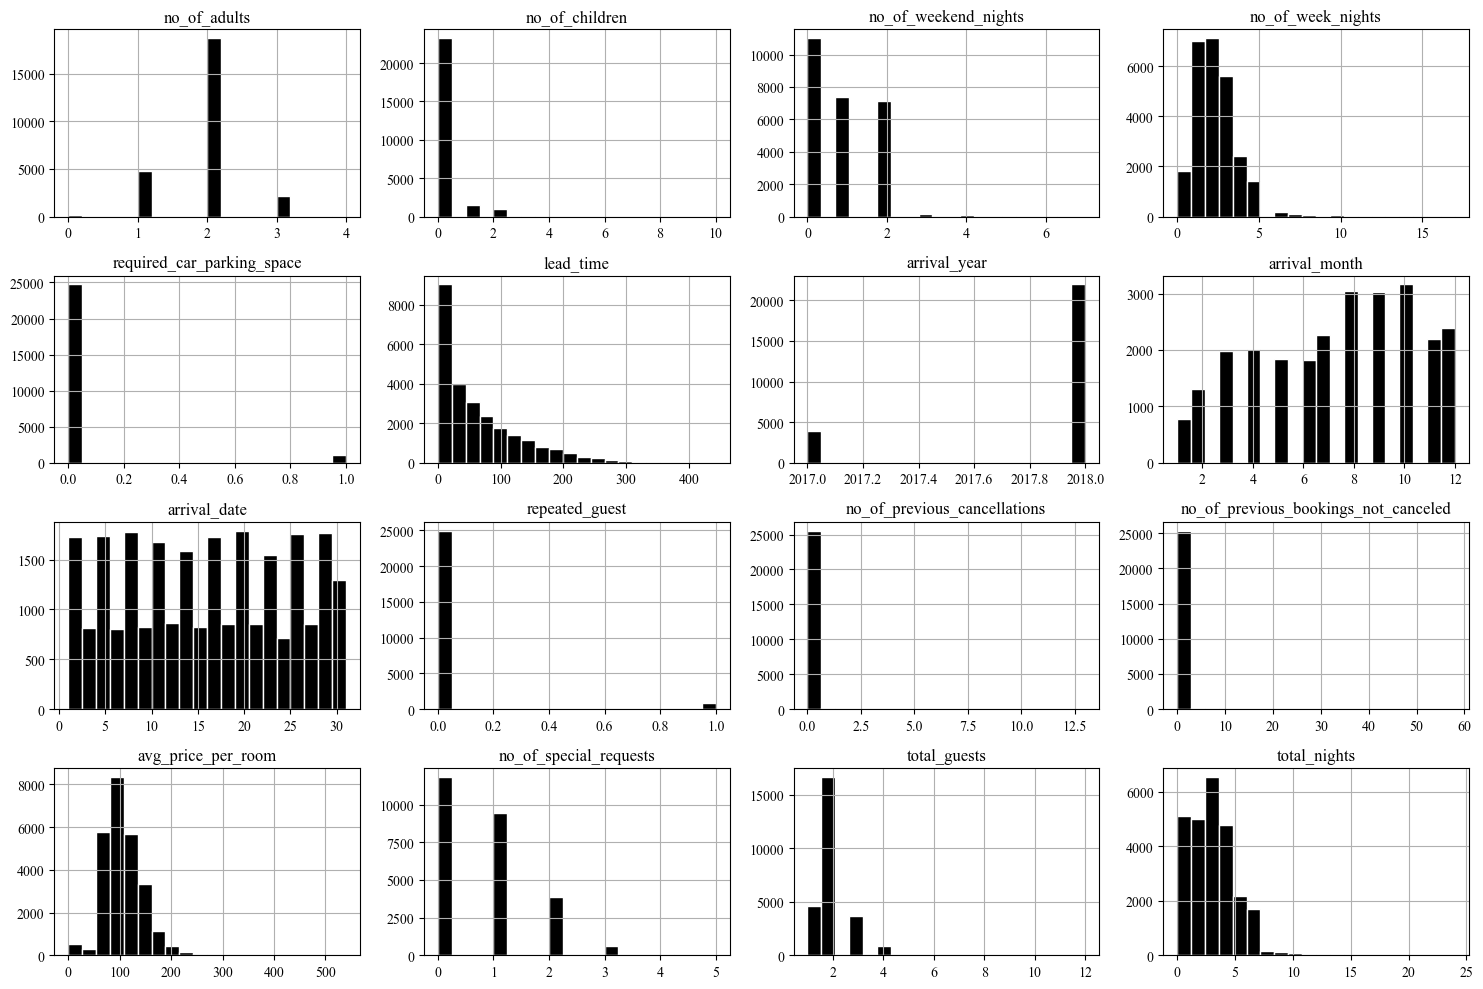

In [22]:
df[num_cols].hist(figsize = (15, 10), bins = 20, color = 'black', edgecolor = 'white')
plt.tight_layout()
plt.show()

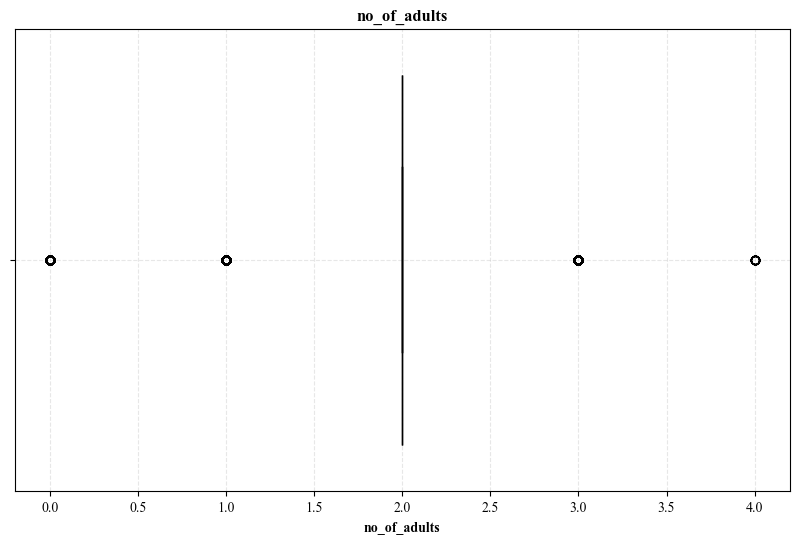

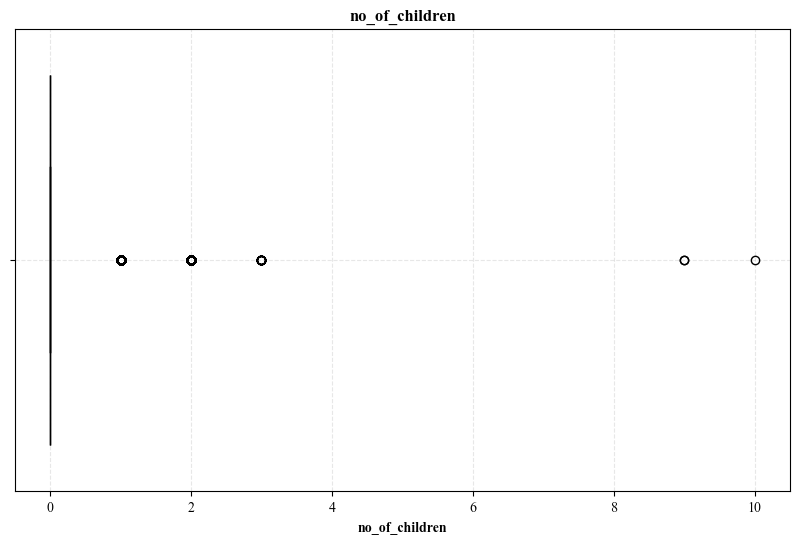

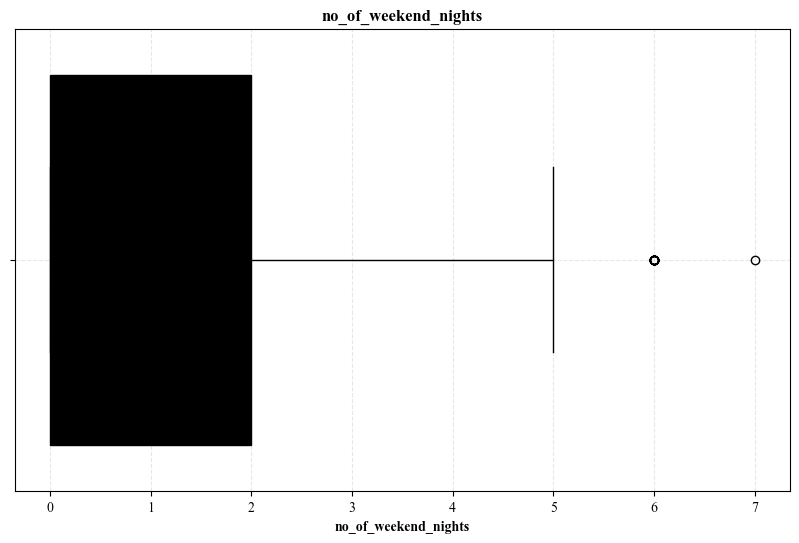

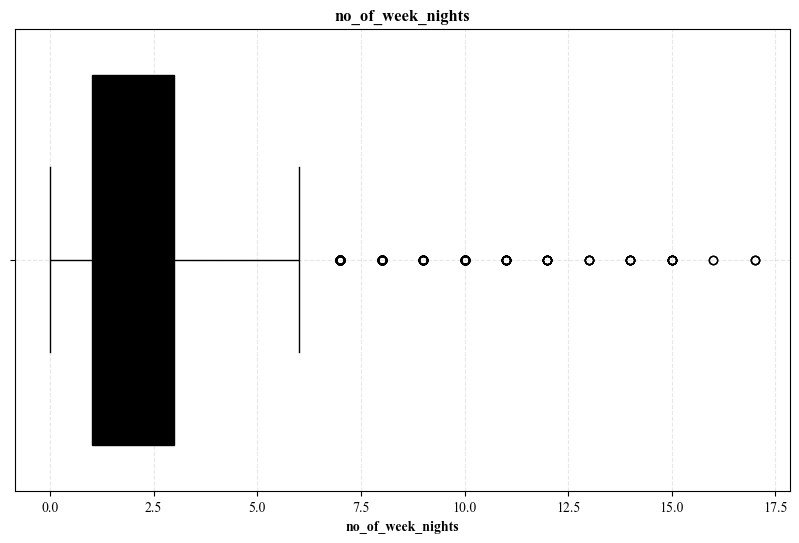

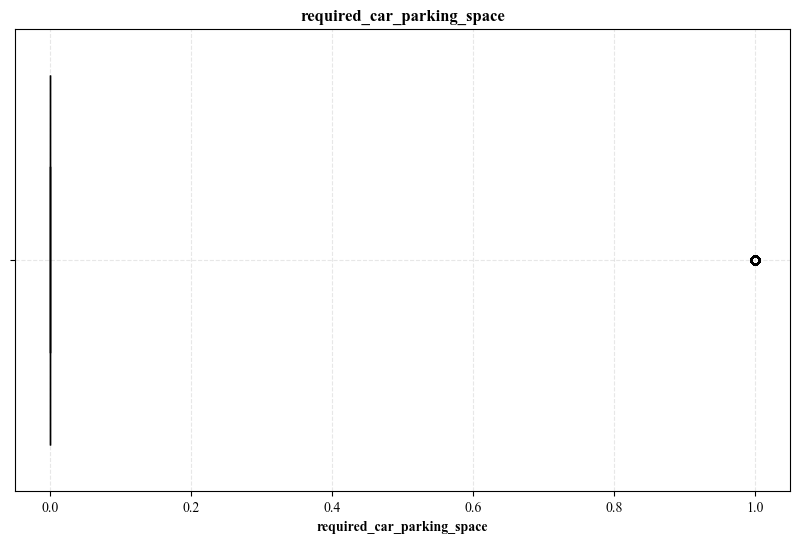

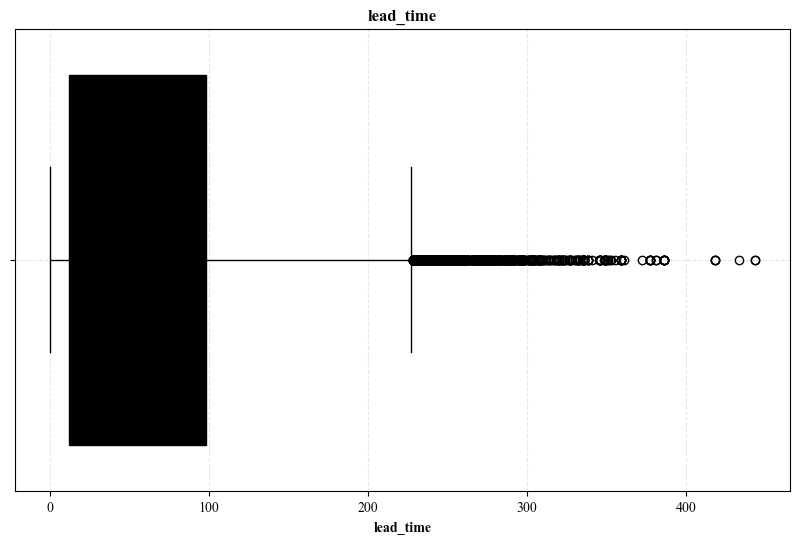

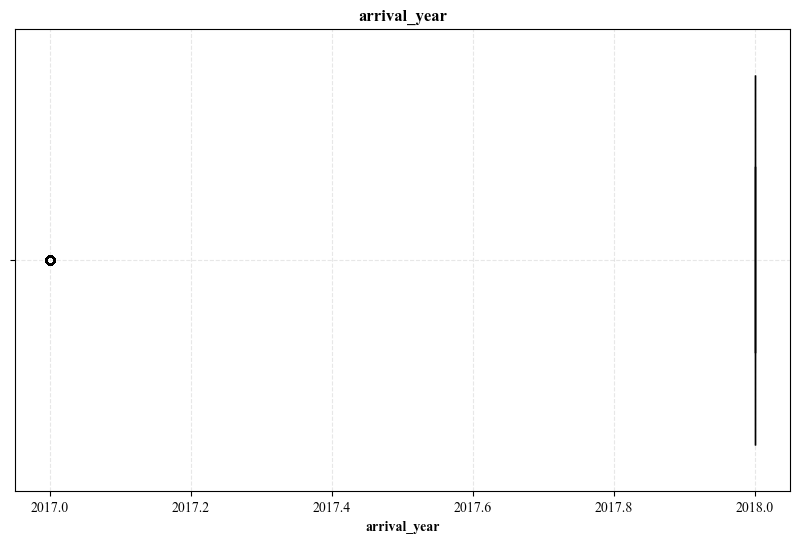

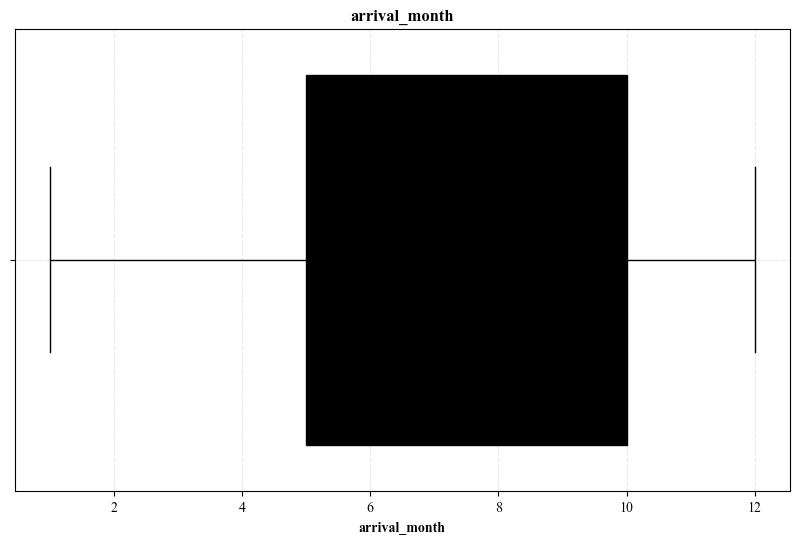

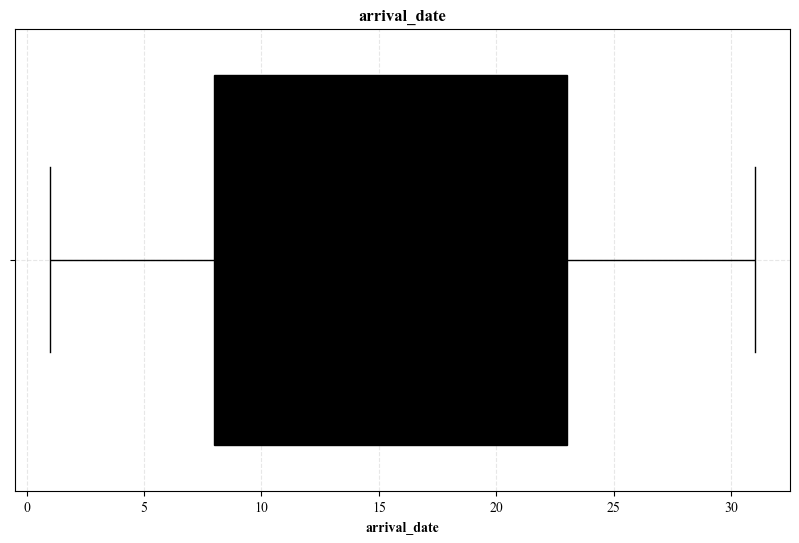

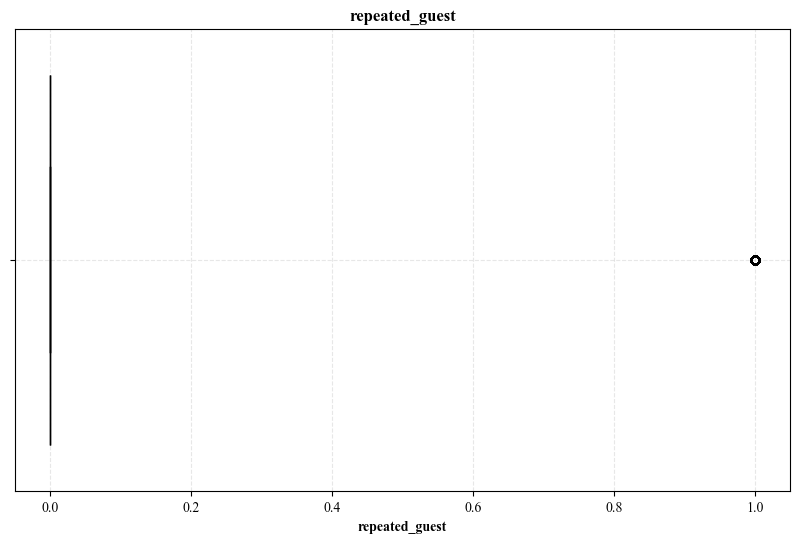

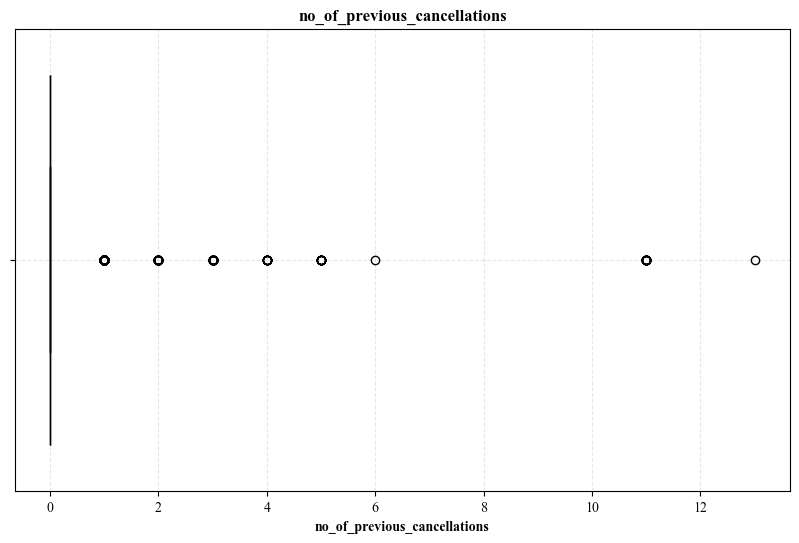

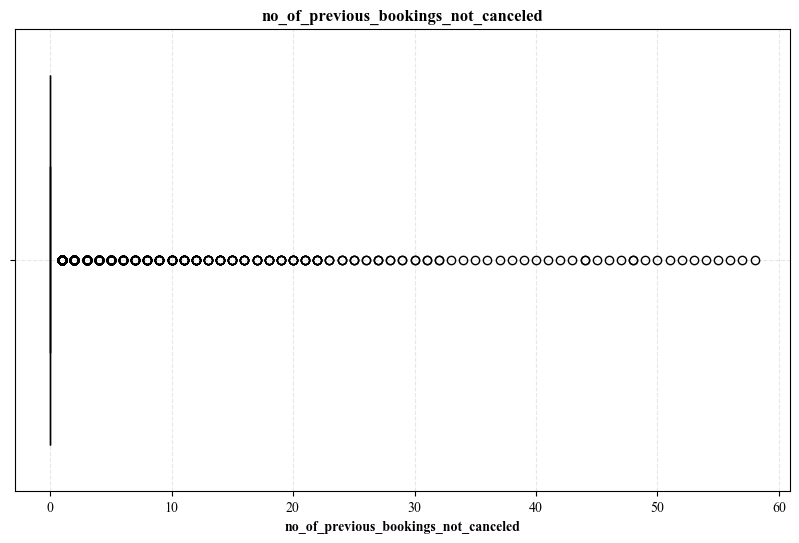

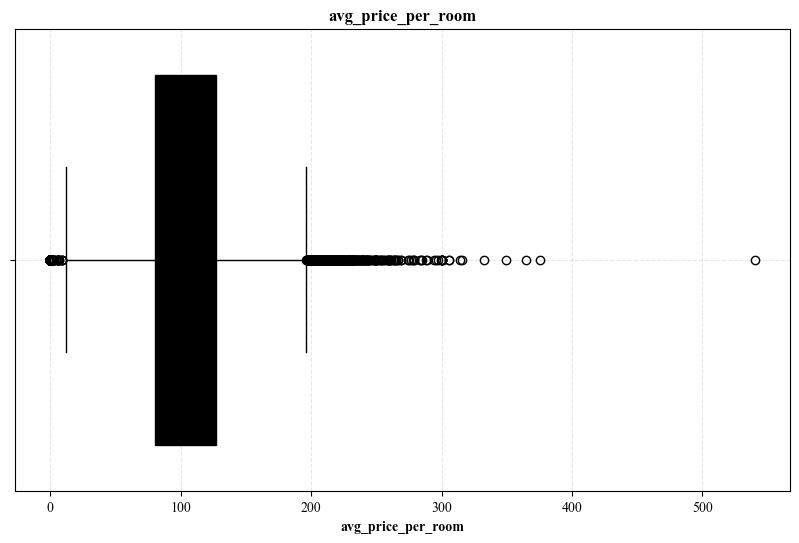

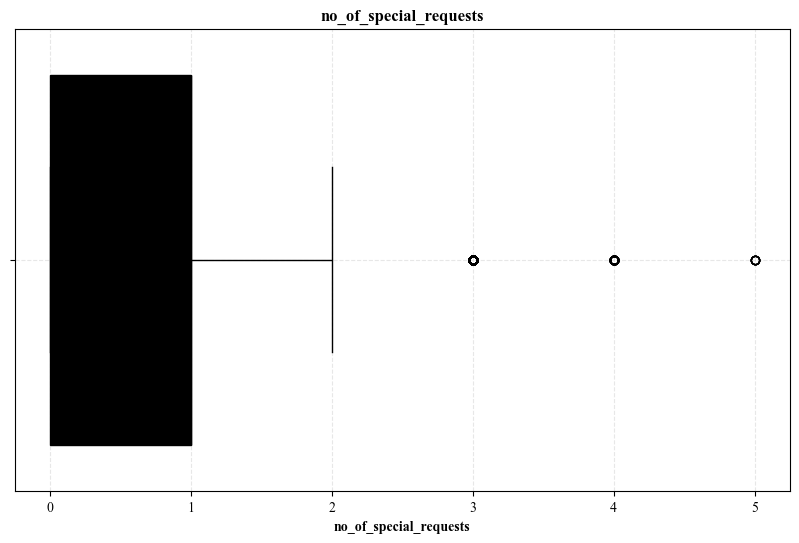

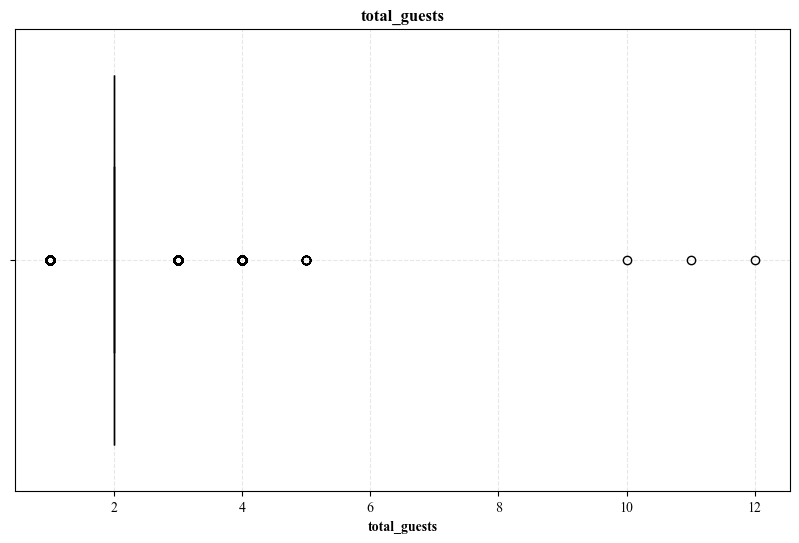

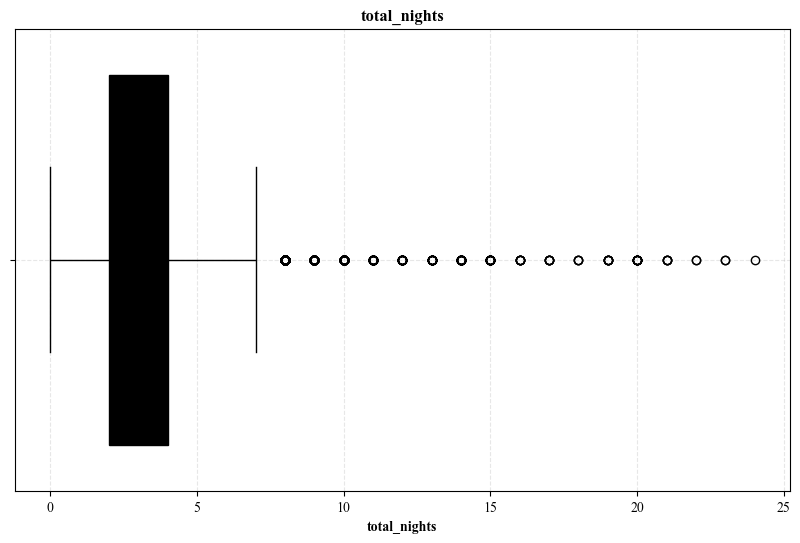

In [23]:
for col in num_cols:
    fig, ax = plt.subplots(figsize = (10, 6))
    sns.boxplot(x = df[col], ax = ax, color = 'black')
    ax.set_title(col, fontweight = 'bold', fontsize = 12)
    ax.set_xlabel(col, fontweight = 'bold')
    ax.grid(True, linestyle = '--', alpha = 0.3)
    plt.show()

In [24]:
df.groupby('booking_status')['lead_time'].mean()

booking_status
Canceled        104.366488
Not_Canceled     50.331194
Name: lead_time, dtype: float64

In [25]:
df.groupby('booking_status')['avg_price_per_room'].mean()

booking_status
Canceled        115.347719
Not_Canceled    101.984183
Name: avg_price_per_room, dtype: float64

In [26]:
df.groupby('booking_status')['total_guests'].mean()

booking_status
Canceled        2.163434
Not_Canceled    1.981879
Name: total_guests, dtype: float64

In [27]:
df.groupby(['type_of_meal_plan', 'booking_status']).size().unstack()

booking_status,Canceled,Not_Canceled
type_of_meal_plan,,
Meal Plan 1,5500,14765
Meal Plan 2,368,710
Meal Plan 3,1,4
Not Selected,1400,3063


In [28]:
pivot_price = pd.pivot_table(df,
                             values = 'avg_price_per_room',
                             index = 'arrival_month',
                             columns = 'booking_status',
                             aggfunc = 'mean')
pivot_price

booking_status,Canceled,Not_Canceled
arrival_month,,
1,80.712500,74.699604
2,85.791088,81.922206
3,102.712011,88.245341
4,114.445248,101.441568
5,127.641138,114.316431
6,121.214241,110.758705
7,116.580144,113.607542
8,120.482596,113.883753
9,128.644103,116.043386


In [29]:
pivot_no_of_adults = pd.pivot_table(df,
                                    values = 'no_of_adults',
                                    index = 'arrival_month',
                                    columns = 'booking_status',
                                    aggfunc = 'mean')
pivot_no_of_adults

booking_status,Canceled,Not_Canceled
arrival_month,,
1,1.875000,1.676781
2,1.764912,1.798834
3,1.959410,1.863510
4,1.915200,1.911238
5,1.912434,1.852498
6,1.996510,1.857714
7,2.046512,2.051787
8,2.097663,1.982646
9,1.947245,1.804428


In [30]:
cancel_rate = df.groupby('arrival_month')['booking_status'].apply(lambda x: (x == 'Canceled').mean())
cancel_rate

arrival_month
1     0.020672
2     0.216895
3     0.274014
4     0.309100
5     0.311681
6     0.314145
7     0.397098
8     0.393820
9     0.282357
10    0.276178
11    0.224154
12    0.142677
Name: booking_status, dtype: float64

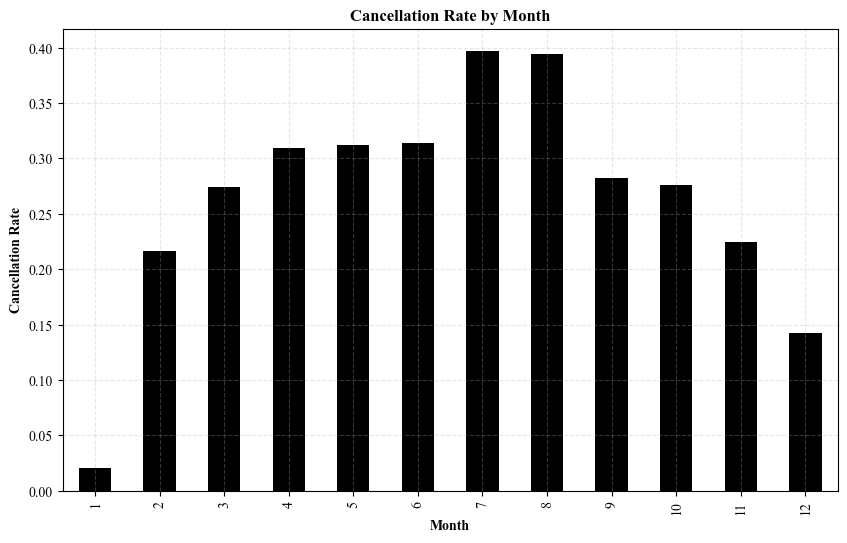

In [31]:
fig, ax = plt.subplots(figsize = (10, 6))
cancel_rate.plot(kind = 'bar', ax = ax, color = 'black', linewidth = 1.5)
ax.set_title('Cancellation Rate by Month', fontweight = 'bold', fontsize = 12)
ax.set_xlabel('Month', fontweight = 'bold')
ax.set_ylabel('Cancellation Rate', fontweight = 'bold')
ax.grid(True, linestyle = '--', alpha = 0.3)

plt.show()

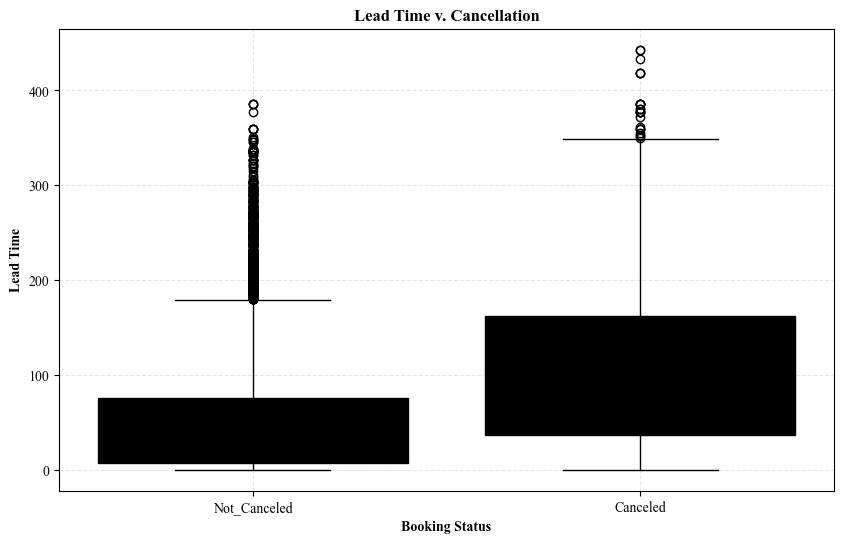

In [32]:
fig, ax = plt.subplots(figsize = (10, 6))
sns.boxplot(data = df, x = 'booking_status', y = 'lead_time', ax = ax, color = 'black')
ax.set_title('Lead Time v. Cancellation', fontweight = 'bold', fontsize = 12)
ax.set_xlabel('Booking Status', fontweight = 'bold')
ax.set_ylabel('Lead Time', fontweight = 'bold')
ax.grid(True, linestyle = '--', alpha = 0.3)

plt.show()

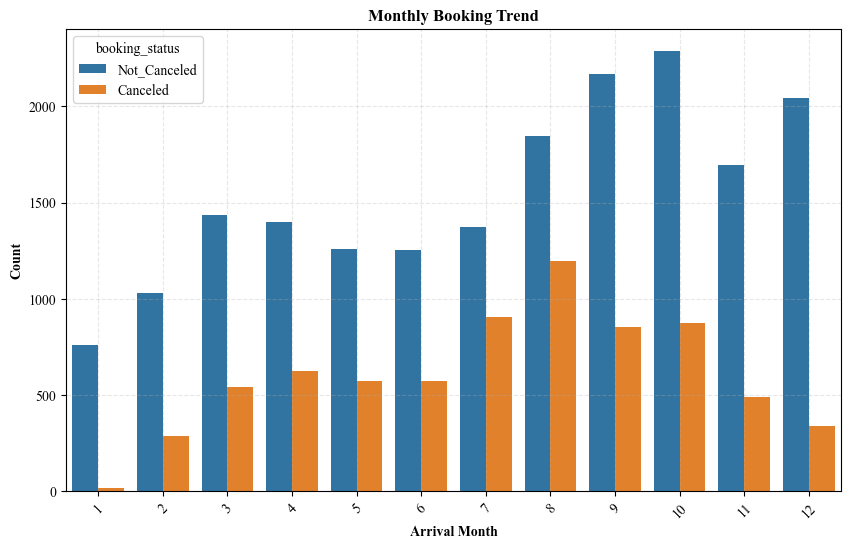

In [33]:
fig, ax = plt.subplots(figsize = (10, 6))
sns.countplot(data = df, x = 'arrival_month', hue = 'booking_status', ax = ax)
ax.set_title('Monthly Booking Trend', fontweight = 'bold', fontsize = 12)
ax.set_xlabel('Arrival Month', fontweight = 'bold')
ax.set_ylabel('Count', fontweight = 'bold')
ax.grid(True, linestyle = '--', alpha = 0.3)
plt.xticks(rotation = 45)

plt.show()

In [34]:
df.head()

,no_of_adults,no_of_children,no_of_weekend_nights,no_of_week_nights,type_of_meal_plan,required_car_parking_space,lead_time,arrival_year,arrival_month,arrival_date,repeated_guest,no_of_previous_cancellations,no_of_previous_bookings_not_canceled,avg_price_per_room,no_of_special_requests,booking_status,total_guests,total_nights
0,2,0,1,2,Meal Plan 1,0,224,2017,10,2,0,0,0,65.00,0,Not_Canceled,2,3
1,2,0,2,3,Not Selected,0,5,2018,11,6,0,0,0,106.68,1,Not_Canceled,2,5
2,1,0,2,1,Meal Plan 1,0,1,2018,2,28,0,0,0,60.00,0,Canceled,1,3
3,2,0,0,2,Meal Plan 1,0,211,2018,5,20,0,0,0,100.00,0,Canceled,2,2
4,2,0,1,1,Not Selected,0,48,2018,4,11,0,0,0,94.50,0,Canceled,2,2


In [35]:
df['booking_status'] = df['booking_status'].replace({'Not_Canceled': 1,
                                                     'Canceled': 0})
df.head()

,no_of_adults,no_of_children,no_of_weekend_nights,no_of_week_nights,type_of_meal_plan,required_car_parking_space,lead_time,arrival_year,arrival_month,arrival_date,repeated_guest,no_of_previous_cancellations,no_of_previous_bookings_not_canceled,avg_price_per_room,no_of_special_requests,booking_status,total_guests,total_nights
0,2,0,1,2,Meal Plan 1,0,224,2017,10,2,0,0,0,65.00,0,1,2,3
1,2,0,2,3,Not Selected,0,5,2018,11,6,0,0,0,106.68,1,1,2,5
2,1,0,2,1,Meal Plan 1,0,1,2018,2,28,0,0,0,60.00,0,0,1,3
3,2,0,0,2,Meal Plan 1,0,211,2018,5,20,0,0,0,100.00,0,0,2,2
4,2,0,1,1,Not Selected,0,48,2018,4,11,0,0,0,94.50,0,0,2,2


In [36]:
df['is_weekend_heavy'] = (df['no_of_weekend_nights'] > df['no_of_week_nights']).astype(int)
df.head()

,no_of_adults,no_of_children,no_of_weekend_nights,no_of_week_nights,type_of_meal_plan,required_car_parking_space,lead_time,arrival_year,arrival_month,arrival_date,repeated_guest,no_of_previous_cancellations,no_of_previous_bookings_not_canceled,avg_price_per_room,no_of_special_requests,booking_status,total_guests,total_nights,is_weekend_heavy
0,2,0,1,2,Meal Plan 1,0,224,2017,10,2,0,0,0,65.00,0,1,2,3,0
1,2,0,2,3,Not Selected,0,5,2018,11,6,0,0,0,106.68,1,1,2,5,0
2,1,0,2,1,Meal Plan 1,0,1,2018,2,28,0,0,0,60.00,0,0,1,3,1
3,2,0,0,2,Meal Plan 1,0,211,2018,5,20,0,0,0,100.00,0,0,2,2,0
4,2,0,1,1,Not Selected,0,48,2018,4,11,0,0,0,94.50,0,0,2,2,0


In [37]:
df.columns

Index(['no_of_adults', 'no_of_children', 'no_of_weekend_nights',
       'no_of_week_nights', 'type_of_meal_plan', 'required_car_parking_space',
       'lead_time', 'arrival_year', 'arrival_month', 'arrival_date',
       'repeated_guest', 'no_of_previous_cancellations',
       'no_of_previous_bookings_not_canceled', 'avg_price_per_room',
       'no_of_special_requests', 'booking_status', 'total_guests',
       'total_nights', 'is_weekend_heavy'],
      dtype='object')

In [38]:
features = ['lead_time',
            'avg_price_per_room',
            'no_of_special_requests',
            'total_guests',
            'total_nights',
            'repeated_guest']

X = df[features]
y = df['booking_status']

In [39]:
X

,lead_time,avg_price_per_room,no_of_special_requests,total_guests,total_nights,repeated_guest
0,224,65.00,0,2,3,0
1,5,106.68,1,2,5,0
2,1,60.00,0,1,3,0
3,211,100.00,0,2,2,0
4,48,94.50,0,2,2,0
...,...,...,...,...,...,...
25806,0,216.00,0,4,1,0
25807,85,167.80,1,3,8,0
25808,228,90.95,2,2,4,0
25809,148,98.39,2,2,8,0


In [40]:
y

0        1
1        1
2        0
3        0
4        0
        ..
25806    0
25807    1
25808    0
25809    1
25810    0
Name: booking_status, Length: 25811, dtype: int64

In [41]:
from sklearn.model_selection import train_test_split

In [42]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.2, stratify = y)

In [43]:
y.value_counts()

booking_status
1    18542
0     7269
Name: count, dtype: int64

In [44]:
from sklearn.utils.class_weight import compute_class_weight
import numpy as np

classes = np.unique(y_train)
classes

array([0, 1])

In [45]:
weights = compute_class_weight(class_weight = 'balanced', classes = classes, y = y_train)
weights

array([1.77540843, 0.69601564])

In [46]:
class_weights = dict(zip(classes, weights))
class_weights

{np.int64(0): np.float64(1.775408426483233),
 np.int64(1): np.float64(0.6960156408009168)}

In [47]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import RandomizedSearchCV

In [48]:
rf = RandomForestClassifier(class_weight = class_weights)

In [49]:
rf_params = {'n_estimators': [100, 200, 300], 
             'max_depth': [5, 10, 20, None],
             'min_samples_split': [2, 5, 10],
             'min_samples_leaf': [1, 2, 4]}

In [50]:
rf_random = RandomizedSearchCV(rf, 
                               rf_params, 
                               n_iter = 20, 
                               cv = 3, 
                               scoring = 'accuracy', 
                               n_jobs = -1)

In [51]:
rf_random.fit(X_train, y_train)

RandomizedSearchCV(cv=3,
                   estimator=RandomForestClassifier(class_weight={np.int64(0): np.float64(1.775408426483233),
                                                                  np.int64(1): np.float64(0.6960156408009168)}),
                   n_iter=20, n_jobs=-1,
                   param_distributions={'max_depth': [5, 10, 20, None],
                                        'min_samples_leaf': [1, 2, 4],
                                        'min_samples_split': [2, 5, 10],
                                        'n_estimators': [100, 200, 300]},
                   scoring='accuracy')

In [52]:
rf_random.best_params_

{'n_estimators': 300,
 'min_samples_split': 2,
 'min_samples_leaf': 2,
 'max_depth': 20}

In [53]:
from sklearn.ensemble import GradientBoostingClassifier

In [54]:
gb = GradientBoostingClassifier()

In [55]:
gb_params = {'n_estimators': [100, 200],
             'learning_rate': [0.01, 0.1, 0.2],
             'max_depth': [3, 5, 7]}

In [56]:
gb_random = RandomizedSearchCV(gb,
                               gb_params,
                               n_iter = 15, 
                               cv = 3,
                               scoring = 'accuracy',
                               n_jobs = -1)

In [57]:
gb_random.fit(X_train, y_train)

RandomizedSearchCV(cv=3, estimator=GradientBoostingClassifier(), n_iter=15,
                   n_jobs=-1,
                   param_distributions={'learning_rate': [0.01, 0.1, 0.2],
                                        'max_depth': [3, 5, 7],
                                        'n_estimators': [100, 200]},
                   scoring='accuracy')

In [58]:
gb_random.best_params_

{'n_estimators': 100, 'max_depth': 5, 'learning_rate': 0.2}

In [59]:
from xgboost import XGBClassifier

In [60]:
xgb = XGBClassifier(scale_pos_weight = class_weights[0] / class_weights[1],
                    eval_metric = 'logloss')

In [61]:
xgb_params = {'n_estimators': [100, 200, 300],
              'max_depth': [3, 5, 7],
              'learning_rate': [0.01, 0.1, 0.2],
              'subsample': [0.7, 1.0],
              'colsample_bytree': [0.7, 1.0]}

In [62]:
xgb_random = RandomizedSearchCV(xgb,
                                xgb_params,
                                n_iter = 20,
                                cv = 3,
                                scoring = 'accuracy',
                                n_jobs = -1)

In [63]:
xgb_random.fit(X_train, y_train)

RandomizedSearchCV(cv=3,
                   estimator=XGBClassifier(base_score=None, booster=None,
                                           callbacks=None,
                                           colsample_bylevel=None,
                                           colsample_bynode=None,
                                           colsample_bytree=None, device=None,
                                           early_stopping_rounds=None,
                                           enable_categorical=True,
                                           eval_metric='logloss',
                                           feature_types=None,
                                           feature_weights=None, gamma=None,
                                           grow_policy=None,
                                           importance_type=None,
                                           interaction_const...
                                           max_delta_step=None, max_depth=None,
                                           max_leaves=None,
                                           min_child_weight=None, missing=nan,
                                           monotone_constraints=None,
                                           multi_strategy=None,
                                           n_estimators=None, n_jobs=None,
                                           num_parallel_tree=None, ...),
                   n_iter=20, n_jobs=-1,
                   param_distributions={'colsample_bytree': [0.7, 1.0],
                                        'learning_rate': [0.01, 0.1, 0.2],
                                        'max_depth': [3, 5, 7],
                                        'n_estimators': [100, 200, 300],
                                        'subsample': [0.7, 1.0]},
                   scoring='accuracy')

In [64]:
xgb_random.best_params_

{'subsample': 1.0,
 'n_estimators': 200,
 'max_depth': 7,
 'learning_rate': 0.2,
 'colsample_bytree': 0.7}

In [65]:
from sklearn.metrics import accuracy_score

In [66]:
models = {'Random Forest': rf_random.best_estimator_,
          'Gradient Boosting': gb_random.best_estimator_,
          'XGBoost': xgb_random.best_estimator_}

In [67]:
for name, model in models.items():
    print(f"{name}")
    y_pred = model.predict(X_test)
    print(accuracy_score(y_test, y_pred))

Random Forest
0.8121247336819678
Gradient Boosting
0.8293627735812512
XGBoost
0.8144489637807476


In [68]:
import joblib

best_model = gb_random.best_estimator_
joblib.dump(best_model, 'Hotel Booking Cancellations Prediction - Gradient Boosting Model.pkl')

['Hotel Booking Cancellations Prediction - Gradient Boosting Model.pkl']

In [69]:
features

['lead_time',
 'avg_price_per_room',
 'no_of_special_requests',
 'total_guests',
 'total_nights',
 'repeated_guest']

In [70]:
import sys
import sklearn

print(sys.executable)
print(sklearn.__version__)

C:\Users\dilan\AppData\Local\Programs\Python\Python312\python.exe
1.5.2
